<a href="https://colab.research.google.com/github/mrmcgruder98/Assignment-1-PSD/blob/main/Assignment_1_part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 25)

local_path = Path("data/StudentsPerformance.csv")
data_url = "https://raw.githubusercontent.com/mrmcgruder98/Assignment-1-PSD/refs/heads/main/StudentsPerformance.csv"
source = local_path if local_path.exists() else data_url

df_raw = pd.read_csv(source)
print(f"Dataset loaded from: {source}")

Dataset loaded from: https://raw.githubusercontent.com/mrmcgruder98/Assignment-1-PSD/refs/heads/main/StudentsPerformance.csv


In [9]:
numeric_columns = df_raw.select_dtypes(include="number").columns.tolist()
categorical_columns = df_raw.select_dtypes(exclude="number").columns.tolist()
missing_columns = df_raw.select_dtypes(include="number").columns.tolist()

column_types = df_raw.dtypes

numeric_summary = print("Numeric columns:", numeric_columns,
                        "Categorical columns:", categorical_columns,
                        "Missing Value columns:", missing_columns)
print(numeric_summary)

Numeric columns: ['math score', 'reading score', 'writing score'] Categorical columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course'] Missing Value columns: ['math score', 'reading score', 'writing score']
None


In [10]:
missing_summary = pd.DataFrame({"missing_count": df_raw.isna().sum(),
    "missing_percent": df_raw.isna().mean().mul(100).round(1),
})
missing_summary.query("missing_count > 0").sort_values("missing_percent", ascending=False)

,missing_count,missing_percent


In [11]:
assert df_raw.isna().sum().sum() == 0, "Missing values remain"
assert not df_raw.duplicated().any(), "Duplicate rows remain"
assert len(df_raw) == len(df_raw.drop_duplicates()), "Duplicate rows remain"

print("All validation checks passed.")

All validation checks passed.


### Above is validation and testing


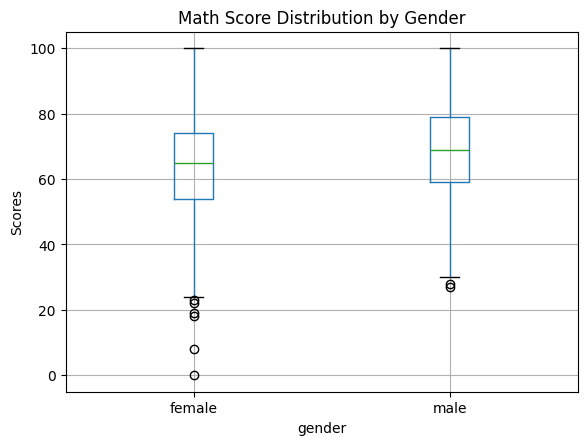

In [16]:

# Plot directly using Pandas (grouped by 'Category')
df_raw.boxplot(column='math score', by='gender')
plt.title('Math Score Distribution by Gender')
plt.suptitle('') # Removes the default automatic subtitle
plt.ylabel('Scores')
plt.show()

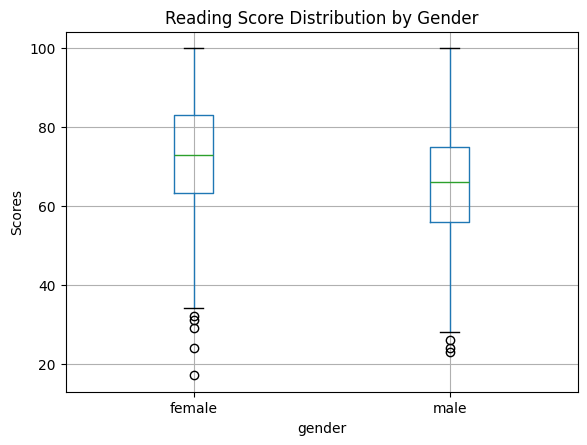

In [17]:
# Plot directly using Pandas (grouped by 'Category')
df_raw.boxplot(column='reading score', by='gender')
plt.title('Reading Score Distribution by Gender')
plt.suptitle('') # Removes the default automatic subtitle
plt.ylabel('Scores')
plt.show()

### Yes, there is a difference in score between the women and men. It seems that the men have the higher scores in math while women have higher scores in reading.

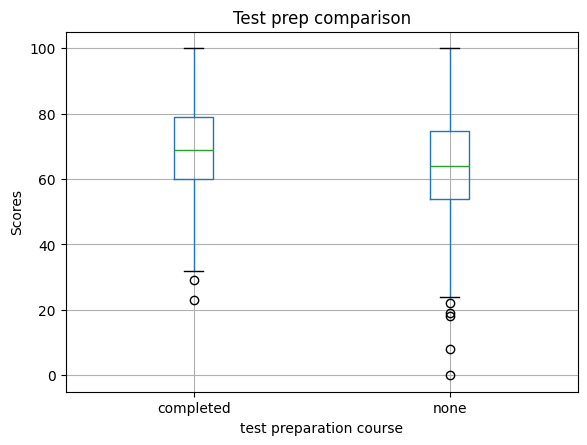

In [23]:
df_raw.boxplot(column='math score', by='test preparation course')
plt.title('Test prep comparison')
plt.suptitle('') # Removes the default automatic subtitle
plt.ylabel('Scores')
plt.show()

### The students who completed the Test Prep Course has significantly higher average score in comparison to those who did not have the prep course.

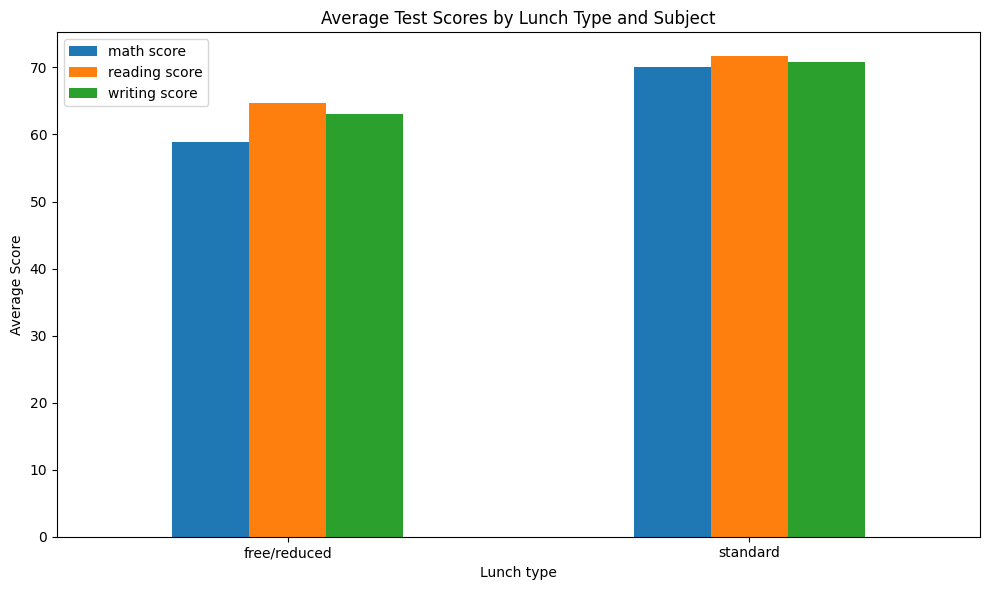

In [31]:
if df_raw.index.name == 'lunch':
    df_raw.reset_index(inplace=True)

# Group by 'lunch' and calculate the mean of 'math score', 'reading score', and 'writing score' for each group.
# Use a list for column selection, not a tuple.
overall_performance = df_raw.groupby('lunch')[['math score', 'reading score', 'writing score']].mean()

# Plot the results as a grouped bar chart.
overall_performance.plot(kind='bar', figsize=(10, 6)) # Increased figsize for better readability

plt.title('Average Test Scores by Lunch Type and Subject') # More specific title
plt.ylabel('Average Score')
plt.xlabel('Lunch type')
plt.xticks(rotation=0) # Keeps category names horizontal
plt.tight_layout()
plt.show()

### It seems that consistantly through every subject, standard lunches show to have the highest average test scores through out.

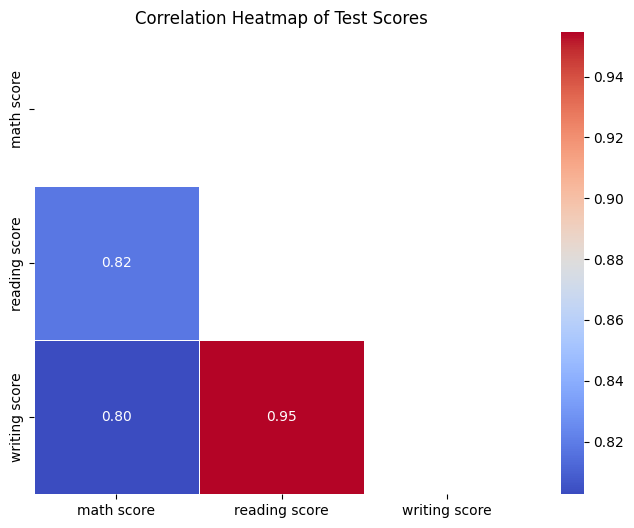

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns for correlation calculation
numeric_df = df_raw.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

# Create a mask to hide the upper triangle of the heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, # Corrected: use the calculated corr_matrix directly
    mask=mask,                  # Applies the diagonal mask
    annot=True,                 # Annotate with the correlation coefficients
    cmap='coolwarm',            # Color map (e.g., 'coolwarm', 'viridis')
    fmt=".2f",                  # Format annotations to two decimal places
    linewidths=.5               # Add lines between cells
)
plt.title('Correlation Heatmap of Test Scores')
plt.show()

### This heat map provided shows the heat graph of reading, writing and math subjects.While reading and writing have without a doubt the highest score, math/writing and math/reading have decent percentage of that being .8 and .82. Only being behind reading and writing by that of most .15.

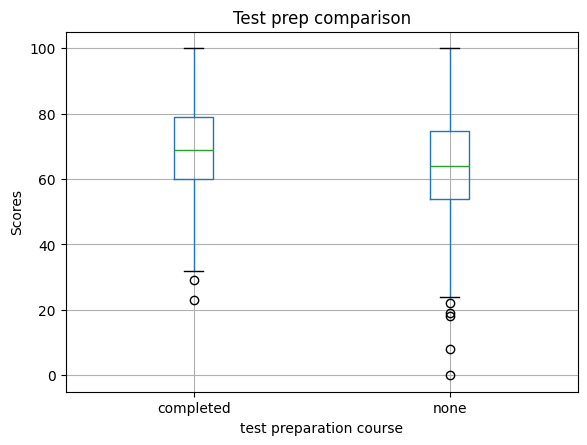

In [42]:
df1 = pd.DataFrame({'Prep': df_raw['test preparation course'], 'Score': df_raw['reading score'], 'Subject': 'Reading'})
df2 = pd.DataFrame({'Prep': df_raw['test preparation course'], 'Score': df_raw['math score'], 'Subject': 'Math'})

df_all = pd.concat([df1, df2])

df_raw.boxplot(column='math score', by='test preparation course')
plt.title('Test prep comparison')
plt.suptitle('') # Removes the default automatic subtitle
plt.ylabel('Scores')
plt.show()

<Figure size 1000x600 with 0 Axes>

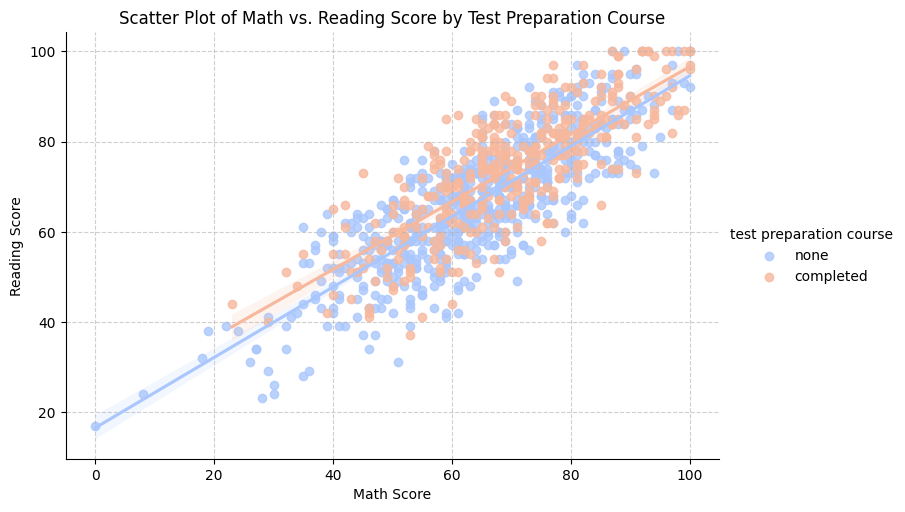

In [43]:
plt.figure(figsize=(10, 6))
sns.lmplot(x='math score', y='reading score', hue='test preparation course', data=df_raw, palette='coolwarm', aspect=1.5)
plt.title('Scatter Plot of Math vs. Reading Score by Test Preparation Course')
plt.xlabel('Math Score')
plt.ylabel('Reading Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### The math and reading scores are strongly coorilated to that of the students who took the test preperation course and those who have not. The blue shows a significant lower result to those in the red(complete) category. Highlighting that if students decide to take the test prep course, they will most likely  recieve a higher test score than without.
